In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Dropout
import scipy.stats as stats

In [2]:
import warnings
warnings.filterwarnings('ignore')
sns.set(style="whitegrid", palette="muted")

In [3]:
# ==========================================
# 1. DATA LOADING & PREPROCESSING
# ==========================================
df = pd.read_csv('crypto_combine.csv')

In [4]:
df.head()

,Crypto,Date,Open,High,Low,Close
0,BTC,12/31/19,7254.0,7309.0,7132.0,7171.0
1,BTC,12/30/19,7402.0,7430.0,7217.0,7254.0
2,BTC,12/29/19,7334.0,7529.0,7295.0,7402.0
3,BTC,12/28/19,7235.0,7359.0,7235.0,7334.0
4,BTC,12/27/19,7208.0,7267.0,7087.0,7235.0


In [5]:
df.tail()

,Crypto,Date,Open,High,Low,Close
7894,XRP,1/5/19,0.36,0.36,0.35,0.36
7895,XRP,1/4/19,0.36,0.36,0.35,0.36
7896,XRP,1/3/19,0.37,0.38,0.35,0.36
7897,XRP,1/2/19,0.36,0.37,0.36,0.37
7898,XRP,1/1/19,0.35,0.36,0.34,0.36


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7899 entries, 0 to 7898
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Crypto  7899 non-null   object 
 1   Date    7899 non-null   object 
 2   Open    7899 non-null   float64
 3   High    7899 non-null   float64
 4   Low     7899 non-null   float64
 5   Close   7899 non-null   float64
dtypes: float64(4), object(2)
memory usage: 370.4+ KB


In [7]:
# Preprocessing
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')
df['Day'] = df['Date'].dt.day
df['Price_Range'] = df['High'] - df['Low']
df['Returns'] = df.groupby('Crypto')['Close'].pct_change()

# Encoding
le = LabelEncoder()
df['Crypto_Enc'] = le.fit_transform(df['Crypto'])

# Features and Target
features = ['Open', 'High', 'Low', 'Crypto_Enc', 'Day', 'Price_Range']
X = df[features].fillna(0)
y = df['Close']

# Scaling
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

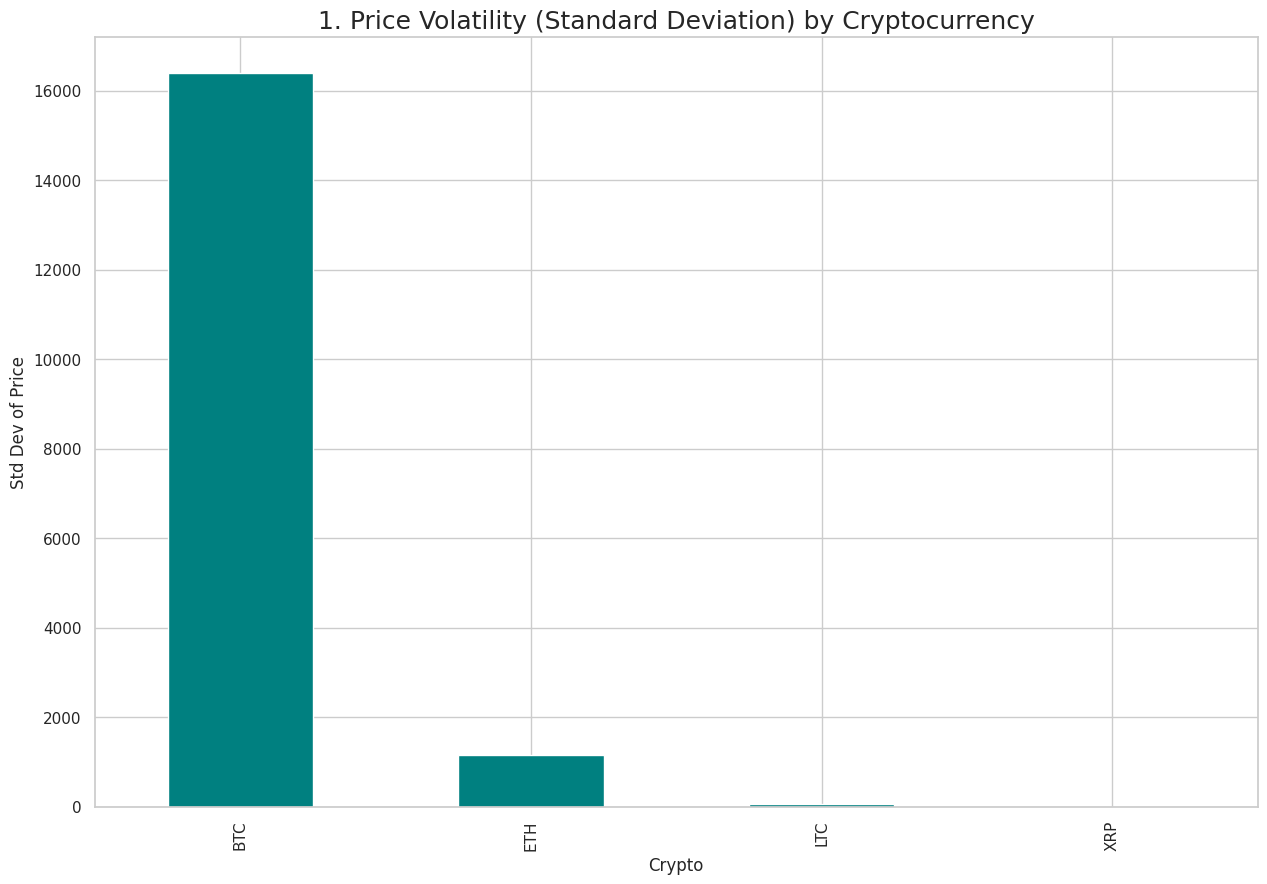

In [8]:
# 1. Volatility Comparison (Standard Deviation of Close Prices)
plt.figure(figsize=(15, 10))
volatility = df.groupby('Crypto')['Close'].std()
volatility.plot(kind='bar', color='teal')
plt.title('1. Price Volatility (Standard Deviation) by Cryptocurrency', fontsize=18)
plt.ylabel('Std Dev of Price')
plt.show()

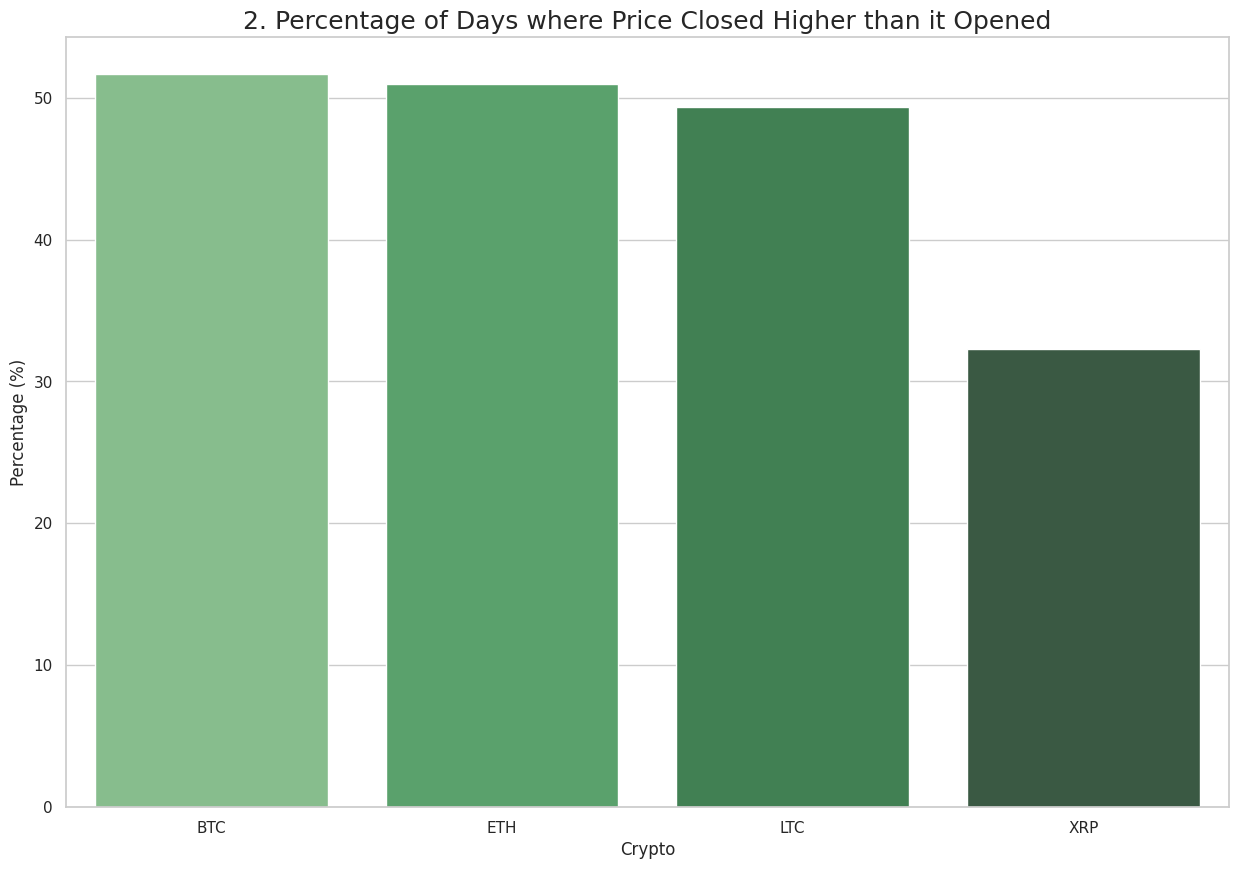

In [9]:
plt.figure(figsize=(15, 10))
df['IsGreen'] = df['Close'] > df['Open']
green_days = df.groupby('Crypto')['IsGreen'].mean() * 100
sns.barplot(x=green_days.index, y=green_days.values, palette='Greens_d')
plt.title('2. Percentage of Days where Price Closed Higher than it Opened', fontsize=18)
plt.ylabel('Percentage (%)')
plt.show()

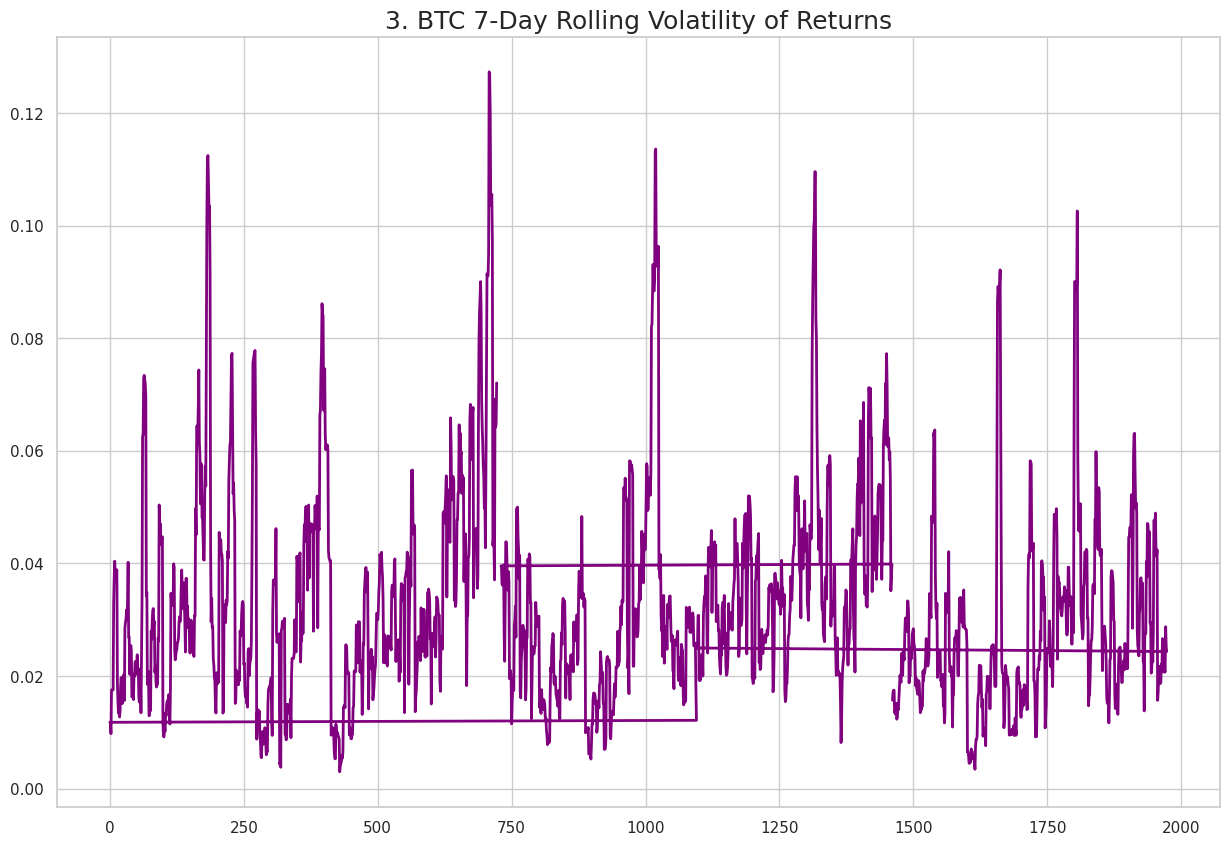

In [10]:
plt.figure(figsize=(15, 10))
btc_returns = df[df['Crypto'] == 'BTC']['Returns']
btc_returns.rolling(window=7).std().plot(color='purple', linewidth=2)
plt.title('3. BTC 7-Day Rolling Volatility of Returns', fontsize=18)
plt.show()

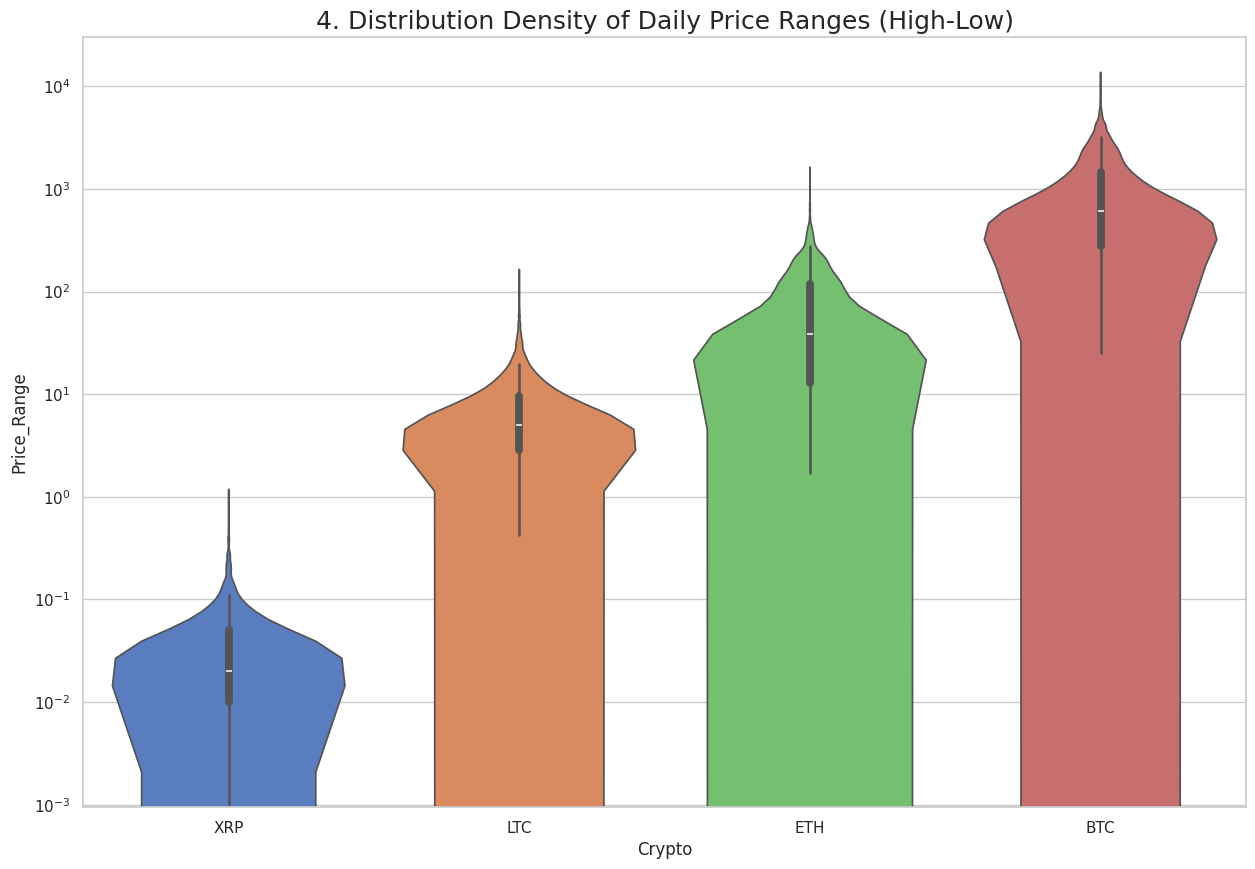

In [11]:
plt.figure(figsize=(15, 10))
sns.violinplot(x='Crypto', y='Price_Range', data=df, palette='muted')
plt.title('4. Distribution Density of Daily Price Ranges (High-Low)', fontsize=18)
plt.yscale('log')
plt.show()

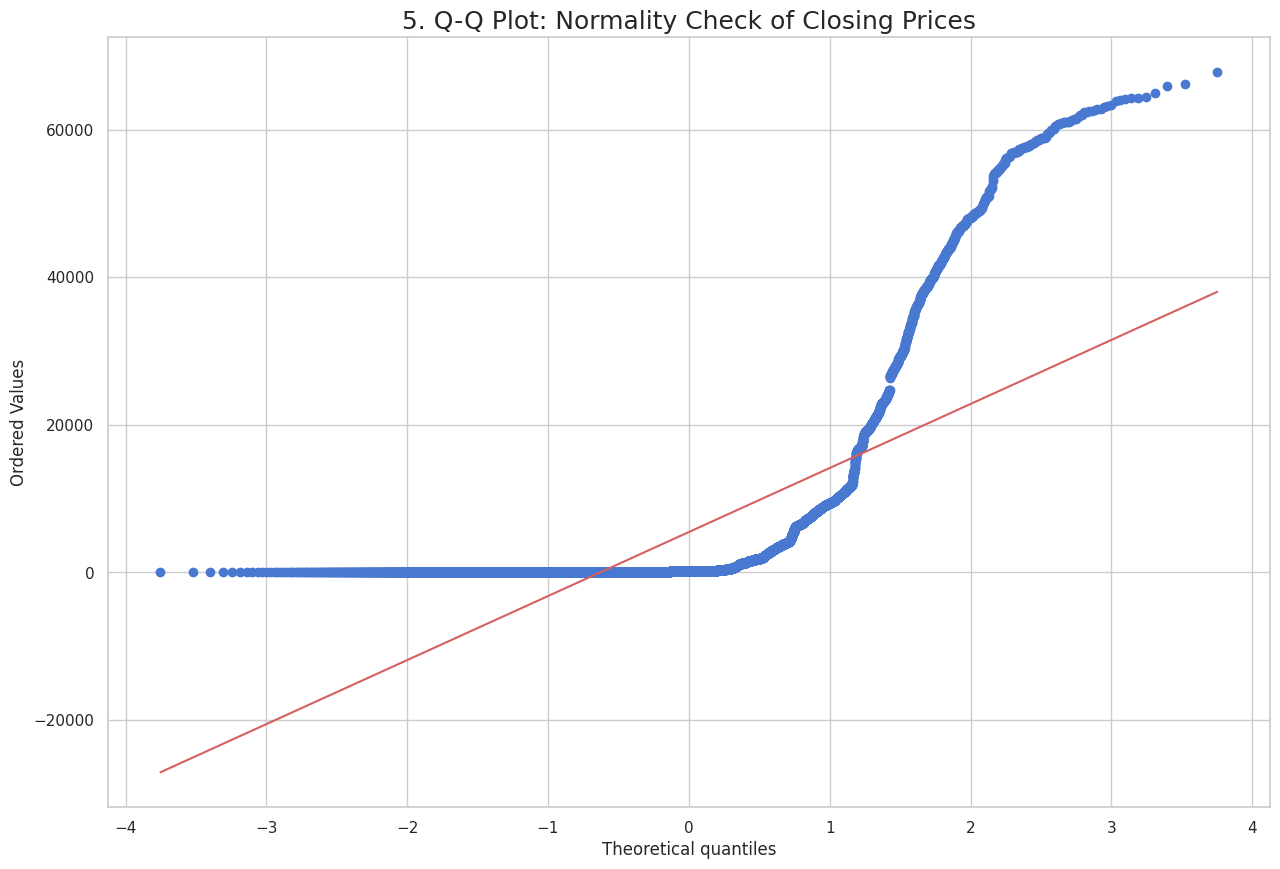

In [12]:
plt.figure(figsize=(15, 10))
stats.probplot(df['Close'], dist="norm", plot=plt)
plt.title('5. Q-Q Plot: Normality Check of Closing Prices', fontsize=18)
plt.show()

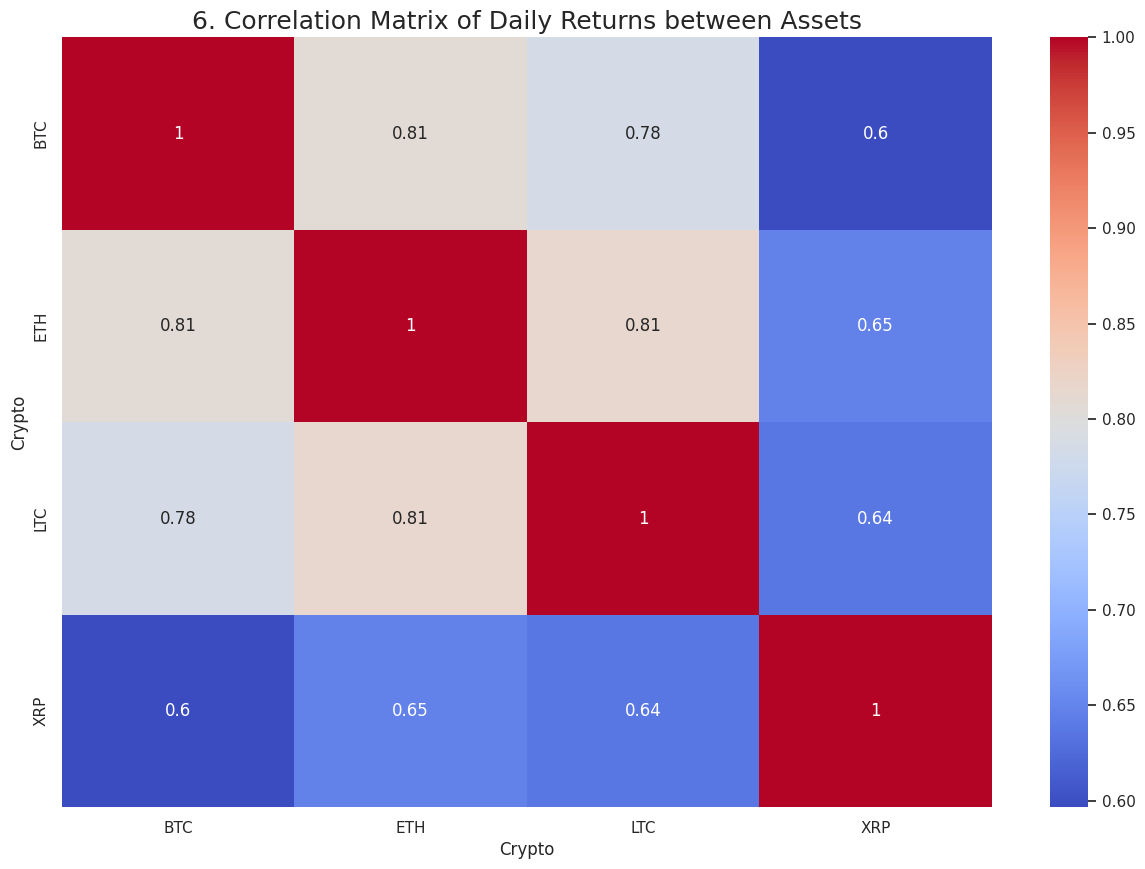

In [13]:
plt.figure(figsize=(15, 10))
pivot_returns = df.pivot_table(index='Date', columns='Crypto', values='Returns')
sns.heatmap(pivot_returns.corr(), annot=True, cmap='coolwarm')
plt.title('6. Correlation Matrix of Daily Returns between Assets', fontsize=18)
plt.show()

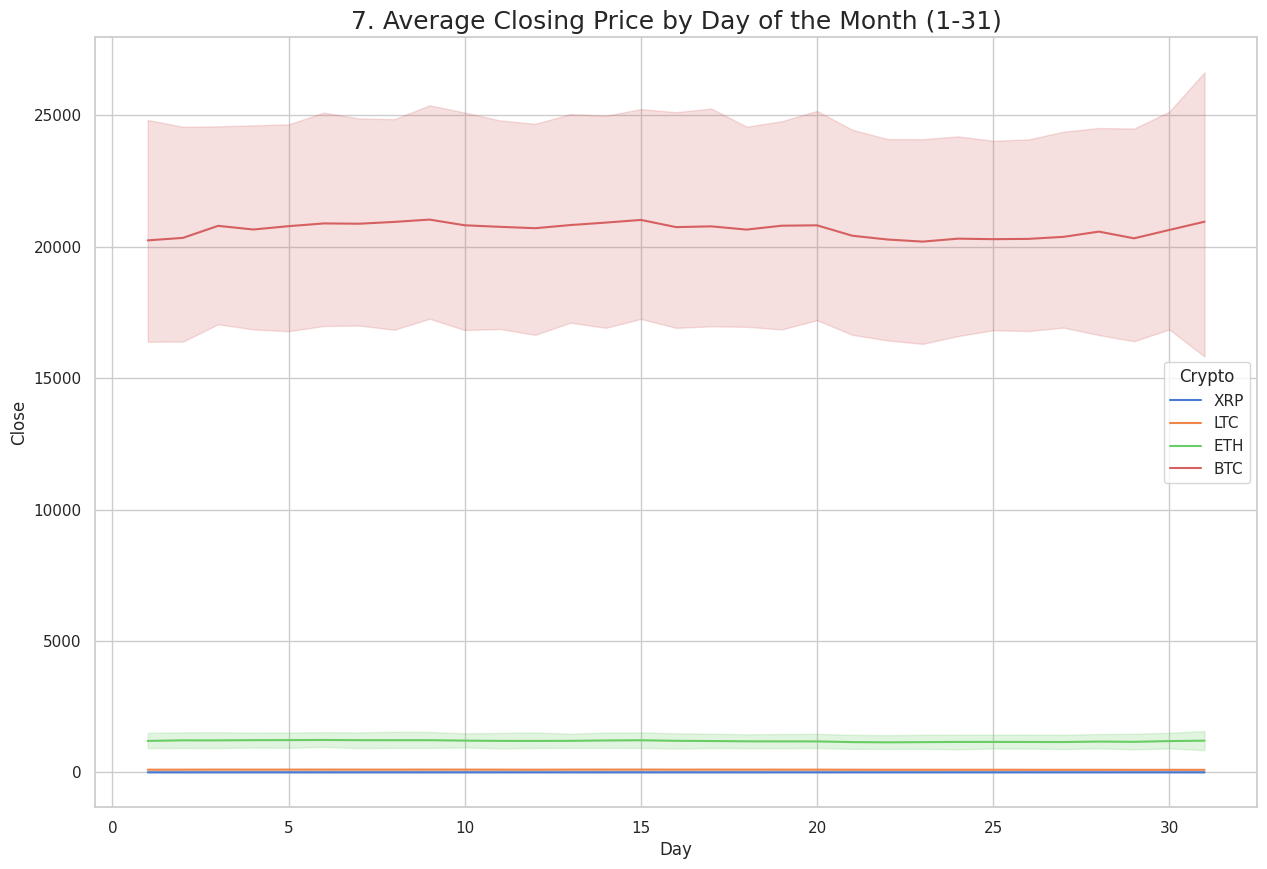

In [14]:
plt.figure(figsize=(15, 10))
sns.lineplot(x='Day', y='Close', data=df, hue='Crypto', estimator='mean')
plt.title('7. Average Closing Price by Day of the Month (1-31)', fontsize=18)
plt.show()

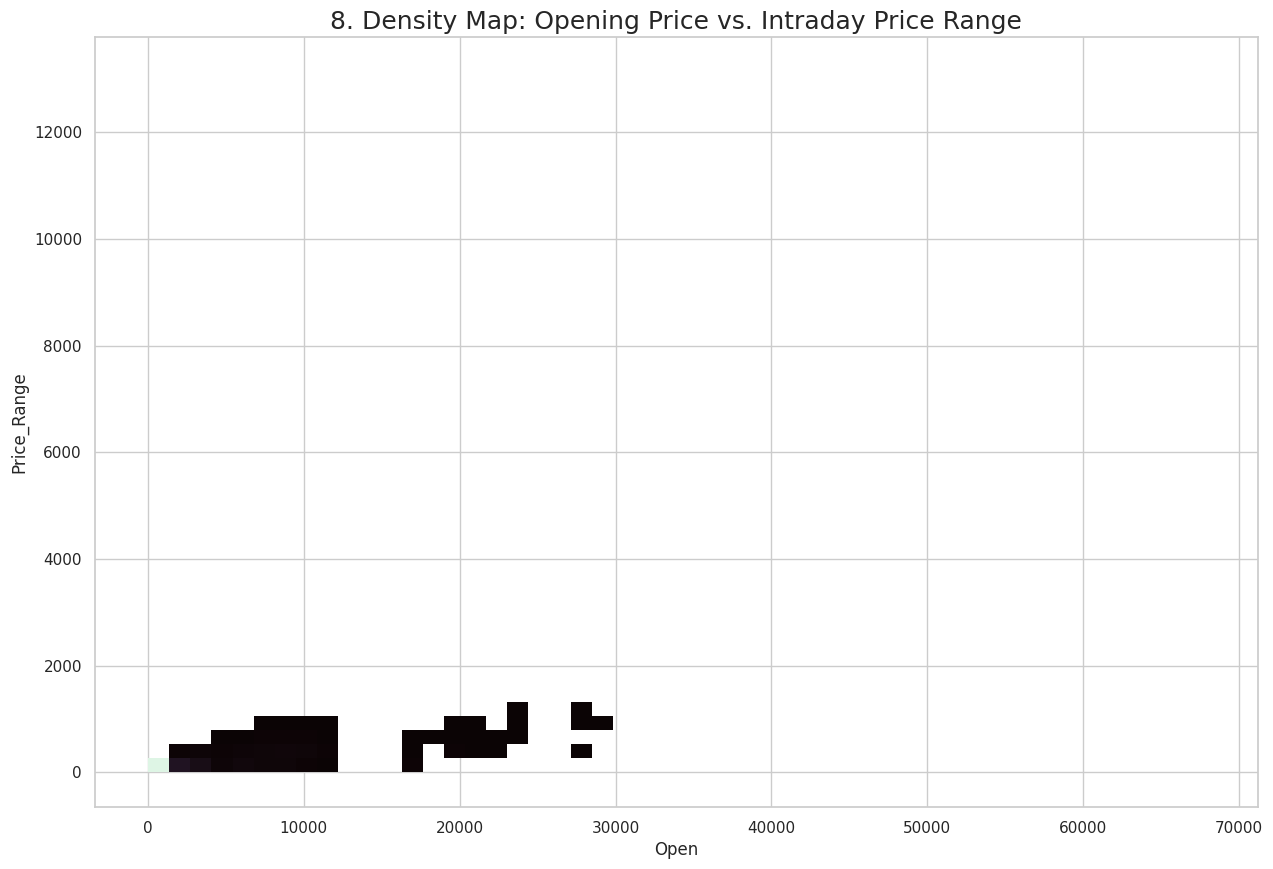

In [15]:
plt.figure(figsize=(15, 10))
sns.histplot(data=df, x='Open', y='Price_Range', bins=50, pthresh=.1, cmap="mako")
plt.title('8. Density Map: Opening Price vs. Intraday Price Range', fontsize=18)
plt.show()

In [16]:
# ==========================================
# 3. MODELS: 2 ML AND 1 DL
# ==========================================

# --- ML Model 1: AdaBoost Regressor ---
ada_model = AdaBoostRegressor(n_estimators=50, random_state=42)
ada_model.fit(X_train, y_train.ravel())
ada_preds = ada_model.predict(X_test)

# --- ML Model 2: Decision Tree Regressor ---
dt_model = DecisionTreeRegressor(max_depth=15, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

# --- DL Model: Simple RNN ---
# Reshape for RNN: [Samples, Time Steps, Features]
X_train_rnn = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_rnn = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

rnn_model = Sequential([
    SimpleRNN(64, input_shape=(1, X_train.shape[1]), activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

rnn_model.compile(optimizer='adam', loss='mse')
rnn_model.fit(X_train_rnn, y_train, epochs=15, batch_size=32, verbose=0)
rnn_preds = rnn_model.predict(X_test_rnn)

50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [19]:
# ==========================================
# 4. EVALUATION & RANKING
# ==========================================

def get_performance(y_true, y_pred, name):
    return {
        'Model': name,
        'R2 Score': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred))
    }

results = [
    get_performance(y_test, ada_preds, 'AdaBoost'),
    get_performance(y_test, dt_preds, 'Decision Tree'),
    get_performance(y_test, rnn_preds, 'Simple RNN (Deep Learning)')
]

# Ranking Table
rank_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
rank_df.index += 1
rank_df.index.name = 'Rank'

print("\n" + "="*40)
print(" MODEL PERFORMANCE RANKING")
print("="*40)
print(rank_df)


 MODEL PERFORMANCE RANKING
                           Model  R2 Score       MAE      RMSE
Rank                                                          
1                  Decision Tree  0.998867  0.001771  0.006035
2     Simple RNN (Deep Learning)  0.998249  0.004663  0.007504
3                       AdaBoost  0.991822  0.014789  0.016216


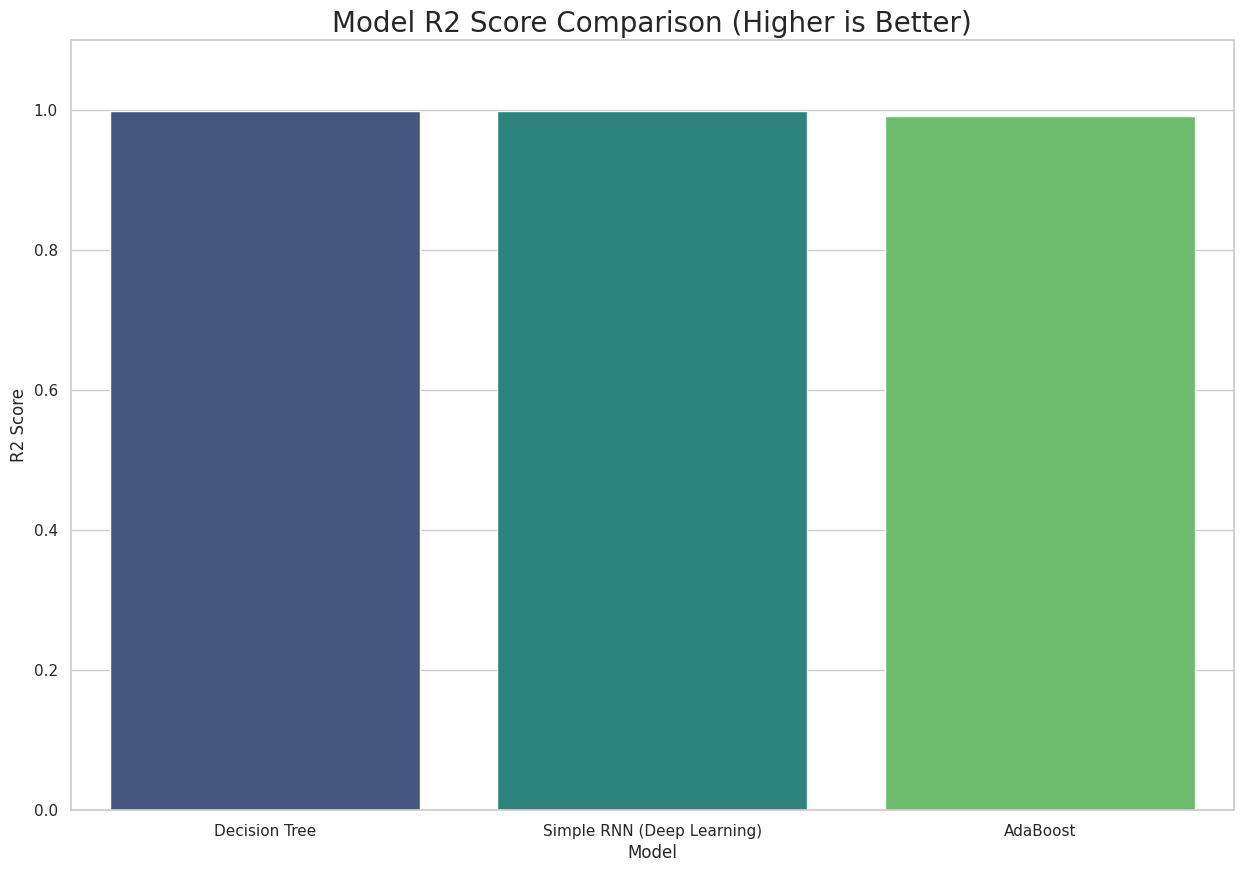

In [18]:
# Comparison Visualization
plt.figure(figsize=(15, 10))
sns.barplot(x='Model', y='R2 Score', data=rank_df, palette='viridis')
plt.title('Model R2 Score Comparison (Higher is Better)', fontsize=20)
plt.ylabel('R2 Score')
plt.ylim(0, 1.1)
plt.show()